Approximating an orbit with semi-major axis 100 and semi-minor axis 70.
Total orbit period: 30.0 units.

--- Moon Positions Over Time ---
At time  0.00: Moon position = ( 100.000,    0.000)
At time  5.00: Moon position = (  50.472,   60.443)
At time  7.50: Moon position = (   0.000,   70.000)
At time 15.00: Moon position = (-100.000,    0.000)
At time 20.00: Moon position = ( -50.472,  -60.443)
At time 22.50: Moon position = (   0.000,  -70.000)
At time 29.99: Moon position = ( 100.000,   -0.155)
At time 30.00: Moon position = ( 100.000,    0.000)
At time 35.00: Moon position = (  50.472,   60.443)

--- Verifying Segment Start/End Points ---
Segment 1 (start): ( 100.000,    0.000)
Segment 1 (end):   (   0.000,   70.000)
Next Segment 2 (start): (   0.000,   70.000)
------------------------------
Segment 2 (start): (   0.000,   70.000)
Segment 2 (end):   (-100.000,    0.000)
Next Segment 3 (start): (-100.000,    0.000)
------------------------------
Segment 3 (start): (-100.000,    0.000

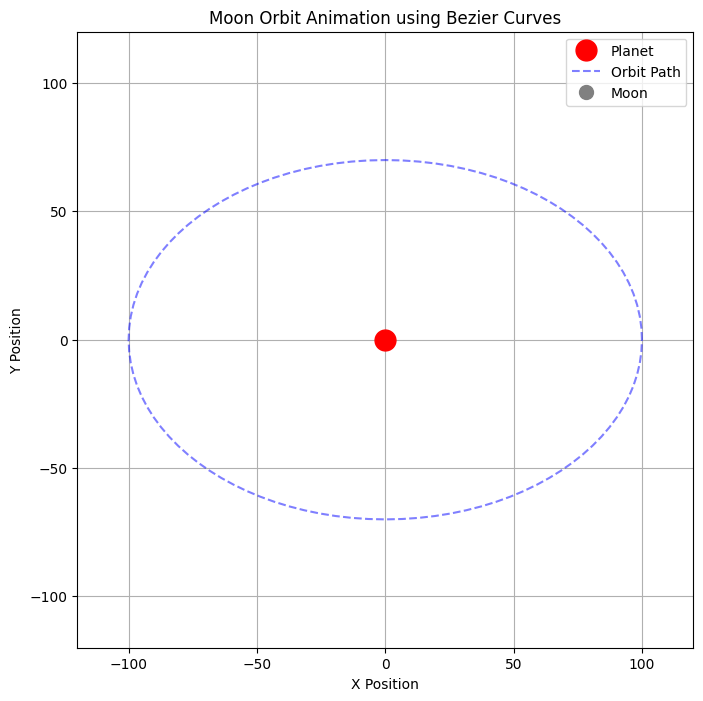

In [2]:
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def lerp(p0, p1, t):
    """
    Linearly interpolates between two points.
    p0: Start point (tuple or list of x, y coordinates)
    p1: End point (tuple or list of x, y coordinates)
    t: Interpolation factor (0.0 to 1.0)
    Returns: Interpolated point (tuple)
    """
    return (p0[0] * (1 - t) + p1[0] * t,
            p0[1] * (1 - t) + p1[1] * t)

def bezier_curve(control_points, t):
    """
    Calculates a point on a Bezier curve using the de Casteljau algorithm.
    Supports any number of control points (degree of the curve).
    control_points: A list of (x, y) tuples representing the control points.
    t: The parameter along the curve (0.0 to 1.0).
    Returns: A tuple (x, y) representing the point on the curve.
    """
    if not control_points:
        raise ValueError("Control points list cannot be empty.")
    if not (0.0 <= t <= 1.0):
        raise ValueError("Parameter 't' must be between 0.0 and 1.0.")

    # Create a copy of the control points for the current iteration
    points = list(control_points)

    # De Casteljau's algorithm
    # Repeatedly interpolate between points until only one point remains
    while len(points) > 1:
        new_points = []
        for i in range(len(points) - 1):
            new_points.append(lerp(points[i], points[i+1], t))
        points = new_points
    
    return points[0]

def approximate_elliptical_orbit_control_points(semi_major_axis, semi_minor_axis, center=(0, 0)):
    """
    Generates control points for a cubic Bezier approximation of an elliptical orbit.
    The orbit is divided into 4 segments (quadrants).
    Uses a common approximation constant for circular arcs (0.5522847498).
    
    semi_major_axis: The semi-major axis of the ellipse (e.g., horizontal radius).
    semi_minor_axis: The semi-minor axis of the ellipse (e.g., vertical radius).
    center: The center of the ellipse (x, y).
    Returns: A list of lists, where each inner list contains 4 control points
             for a cubic Bezier segment.
    """
    cx, cy = center
    a = semi_major_axis
    b = semi_minor_axis
    
    # Approximation constant for a circular arc using cubic Bezier
    # This value is derived from approximating a quarter circle.
    # For a perfect ellipse, these might need slight adjustments or
    # more sophisticated methods for exact fit.
    kappa = 0.5522847498
    
    # Define control points for 4 cubic Bezier segments (one for each quadrant)
    # Each segment has 4 control points: P0, P1, P2, P3
    
    # Segment 1: From (a, 0) to (0, b) (Top-Right Quadrant)
    # P0: Start point (a, 0)
    # P1: Control point 1 (a, b * kappa)
    # P2: Control point 2 (a * kappa, b)
    # P3: End point (0, b)
    segment1_cps = [
        (cx + a, cy),
        (cx + a, cy + b * kappa),
        (cx + a * kappa, cy + b),
        (cx, cy + b)
    ]

    # Segment 2: From (0, b) to (-a, 0) (Top-Left Quadrant)
    segment2_cps = [
        (cx, cy + b),
        (cx - a * kappa, cy + b),
        (cx - a, cy + b * kappa),
        (cx - a, cy)
    ]

    # Segment 3: From (-a, 0) to (0, -b) (Bottom-Left Quadrant)
    segment3_cps = [
        (cx - a, cy),
        (cx - a, cy - b * kappa),
        (cx - a * kappa, cy - b),
        (cx, cy - b)
    ]

    # Segment 4: From (0, -b) to (a, 0) (Bottom-Right Quadrant)
    segment4_cps = [
        (cx, cy - b),
        (cx + a * kappa, cy - b),
        (cx + a, cy - b * kappa),
        (cx + a, cy)
    ]
    
    return [segment1_cps, segment2_cps, segment3_cps, segment4_cps]

def get_moon_position_at_time(current_time, total_orbit_period, orbit_control_points_sets):
    """
    Calculates the moon's position at a given time along the approximated orbit.
    
    current_time: The current time (e.g., in seconds, days, etc.).
    total_orbit_period: The total time for one complete orbit.
    orbit_control_points_sets: A list of lists of control points,
                               where each inner list defines a Bezier segment.
    Returns: A tuple (x, y) representing the moon's position.
    """
    if total_orbit_period <= 0:
        raise ValueError("Total orbit period must be greater than 0.")
    if not orbit_control_points_sets:
        raise ValueError("Orbit control points sets cannot be empty.")

    num_segments = len(orbit_control_points_sets)
    time_per_segment = total_orbit_period / num_segments

    # Normalize current_time to be within one orbit period
    normalized_time = current_time % total_orbit_period

    # Determine which segment the moon is on
    segment_index = int(normalized_time // time_per_segment)
    
    # Ensure segment_index does not exceed bounds (e.g., for time = total_orbit_period exactly)
    if segment_index == num_segments:
        segment_index = num_segments - 1 # Use the last segment's end point

    # Calculate the 't' value for the current segment
    # This 't' value ranges from 0.0 to 1.0 for the current segment
    t_in_segment = (normalized_time % time_per_segment) / time_per_segment

    # Get the control points for the current segment
    current_segment_cps = orbit_control_points_sets[segment_index]

    # Calculate the position using the Bezier curve function
    position = bezier_curve(current_segment_cps, t_in_segment)
    
    return position

# --- Example Usage ---
if __name__ == "__main__":
    # Define orbit parameters
    semi_major = 100  # Distance along x-axis from center
    semi_minor = 70   # Distance along y-axis from center
    planet_center = (0, 0) # Center of the planet/orbit

    # Generate control points for the elliptical orbit
    # This creates 4 cubic Bezier segments to approximate the ellipse
    orbit_cps = approximate_elliptical_orbit_control_points(semi_major, semi_minor, planet_center)

    # Define the total period of the moon's orbit (e.g., 30 days)
    orbit_period = 30.0 # units can be anything, e.g., days, seconds

    print(f"Approximating an orbit with semi-major axis {semi_major} and semi-minor axis {semi_minor}.")
    print(f"Total orbit period: {orbit_period} units.")
    print("\n--- Moon Positions Over Time ---")

    # Simulate moon's position at various times
    simulation_times = [0, 5, 7.5, 15, 20, 22.5, 29.99, 30, 35] # Times in units (e.g., days)

    for t_sim in simulation_times:
        moon_pos = get_moon_position_at_time(t_sim, orbit_period, orbit_cps)
        print(f"At time {t_sim:5.2f}: Moon position = ({moon_pos[0]:8.3f}, {moon_pos[1]:8.3f})")

    print("\n--- Verifying Segment Start/End Points ---")
    # Check if segments connect smoothly (position-wise)
    num_segments = len(orbit_cps)
    for i in range(num_segments):
        start_point_bezier = bezier_curve(orbit_cps[i], 0.0)
        end_point_bezier = bezier_curve(orbit_cps[i], 1.0)
        
        print(f"Segment {i+1} (start): ({start_point_bezier[0]:8.3f}, {start_point_bezier[1]:8.3f})")
        print(f"Segment {i+1} (end):   ({end_point_bezier[0]:8.3f}, {end_point_bezier[1]:8.3f})")

        # Check connection to the next segment's start point
        if i < num_segments - 1:
            next_segment_start = bezier_curve(orbit_cps[i+1], 0.0)
            print(f"Next Segment {i+2} (start): ({next_segment_start[0]:8.3f}, {next_segment_start[1]:8.3f})")
            # Note: For perfect C1 continuity (tangent smoothness), you'd need to ensure
            # the last control point of segment i, its end point, and the first control point
            # of segment i+1 are collinear. This approximation focuses on position continuity.
        print("-" * 30)

    print("\n--- Visualizing a full orbit (more points) ---")
    # Generate many points to visualize the full orbit
    num_points_for_visualization = 100
    time_step = orbit_period / num_points_for_visualization
    
    orbit_points = []
    for i in range(num_points_for_visualization + 1):
        t_vis = i * time_step
        pos = get_moon_position_at_time(t_vis, orbit_period, orbit_cps)
        orbit_points.append(pos)
    
    # Print a subset of points or use a plotting library if available
    print("First 5 points of the orbit:")
    for i in range(min(5, len(orbit_points))):
        print(f"Point {i+1}: ({orbit_points[i][0]:.3f}, {orbit_points[i][1]:.3f})")
    print("...")
    print("Last 5 points of the orbit:")
    for i in range(max(0, len(orbit_points) - 5), len(orbit_points)):
        print(f"Point {i+1}: ({orbit_points[i][0]:.3f}, {orbit_points[i][1]:.3f})")

    # --- Animation Setup ---
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal', adjustable='box')
    ax.set_title('Moon Orbit Animation using Bezier Curves')
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.grid(True)

    # Set plot limits based on orbit dimensions
    max_dim = max(semi_major, semi_minor) * 1.2 # Add some padding
    ax.set_xlim(planet_center[0] - max_dim, planet_center[0] + max_dim)
    ax.set_ylim(planet_center[1] - max_dim, planet_center[1] + max_dim)

    # Plot the planet
    planet_plot, = ax.plot(planet_center[0], planet_center[1], 'o', color='red', markersize=15, label='Planet')

    # Plot the orbit path (static)
    x_orbit = [p[0] for p in orbit_points]
    y_orbit = [p[1] for p in orbit_points]
    orbit_path, = ax.plot(x_orbit, y_orbit, 'b--', alpha=0.5, label='Orbit Path')

    # Plot the moon (animated)
    moon_plot, = ax.plot([], [], 'o', color='gray', markersize=10, label='Moon')

    ax.legend()

    # Animation parameters
    num_frames = 200 # Number of frames for one full orbit
    frame_interval_ms = orbit_period * 1000 / num_frames # Milliseconds per frame

    def init():
        """
        Initialization function for the animation.
        Sets up the initial state of the plot elements.
        """
        moon_plot.set_data([], [])
        return moon_plot,

    def animate(frame):
        """
        Animation function called for each frame.
        Updates the moon's position based on the current frame.
        """
        # Calculate current time based on frame number and total period
        current_animation_time = (frame / num_frames) * orbit_period
        
        # Get the moon's position at this time
        moon_pos = get_moon_position_at_time(current_animation_time, orbit_period, orbit_cps)
        
        # Update the moon's plot data
        moon_plot.set_data([moon_pos[0]], [moon_pos[1]])
        return moon_plot,

    # Create the animation
    ani = animation.FuncAnimation(
        fig, animate, init_func=init, 
        frames=num_frames, interval=frame_interval_ms, blit=True, repeat=True
    )

    plt.show()